In [30]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

In [31]:
df = pd.read_csv("dataset_house.csv")

In [32]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [33]:
x=df[[	"bedrooms",	"bathrooms", "floors", "sqft_living", "view"]]
print(x)

      bedrooms  bathrooms  floors  sqft_living  view
0          3.0       1.50     1.5         1340     0
1          5.0       2.50     2.0         3650     4
2          3.0       2.00     1.0         1930     0
3          3.0       2.25     1.0         2000     0
4          4.0       2.50     1.0         1940     0
...        ...        ...     ...          ...   ...
4595       3.0       1.75     1.0         1510     0
4596       3.0       2.50     2.0         1460     0
4597       3.0       2.50     2.0         3010     0
4598       4.0       2.00     1.0         2090     0
4599       3.0       2.50     2.0         1490     0

[4600 rows x 5 columns]


In [34]:
y=df["price"]
print(y)

0       3.130000e+05
1       2.384000e+06
2       3.420000e+05
3       4.200000e+05
4       5.500000e+05
            ...     
4595    3.081667e+05
4596    5.343333e+05
4597    4.169042e+05
4598    2.034000e+05
4599    2.206000e+05
Name: price, Length: 4600, dtype: float64


In [35]:
df.count()


date             4600
price            4600
bedrooms         4600
bathrooms        4600
sqft_living      4600
sqft_lot         4600
floors           4600
waterfront       4600
view             4600
condition        4600
sqft_above       4600
sqft_basement    4600
yr_built         4600
yr_renovated     4600
street           4600
city             4600
statezip         4600
country          4600
dtype: int64

In [36]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 93)
print(x_train)
print("------x_Train  count Value----")

print(x_train.count())
print(x_test.count())

      bedrooms  bathrooms  floors  sqft_living  view
1193       4.0       3.00     1.0         2170     0
3529       2.0       1.75     1.0         1220     0
464        5.0       2.75     1.0         3060     0
1853       1.0       1.00     1.0          790     0
535        2.0       1.75     1.5         2040     3
...        ...        ...     ...          ...   ...
1716       3.0       2.50     2.0         2240     0
4532       4.0       2.25     2.0         2420     0
237        3.0       1.00     1.0         1110     0
3460       3.0       3.00     2.5         3760     3
2469       4.0       2.50     2.0         2220     0

[3680 rows x 5 columns]
------x_Train  count Value----
bedrooms       3680
bathrooms      3680
floors         3680
sqft_living    3680
view           3680
dtype: int64
bedrooms       920
bathrooms      920
floors         920
sqft_living    920
view           920
dtype: int64


In [37]:
model = LinearRegression()

In [38]:
model.fit(x_train,y_train)

LinearRegression()

In [39]:
m = model.coef_
print("Slope : ", m)

Slope :  [-43124.7042572   32653.40079143   2431.27795841    223.40966423
  73526.54123008]


In [40]:
b = model.intercept_
print(" Intercept: ", b)

 Intercept:  129061.9930862881


In [41]:
y_pred = model.predict(x_test)
y_pred=np.array((y_pred), dtype=int)
print(y_pred)

[ 395838  428576  251479  550786  519694  352803  619024  421101  684244
  626158  443639  654332  281876  314711  278965  800020  249245  334141
  572707 1209530  435214  461069  477038 1016832  490347  336290  477726
  594570  240986  502056  718529  857646  380972  740575  313693  306655
  260955  487532  394480  799334  958276  440520  467340  667049  457704
  547288  984394  367999  295484  392452  535663  722224  496383  528876
  264884  646265  269352  238752  524642  573781  251479  282085  493376
 1057254  724738  300641  630626  525624  413236  789238  689289  577374
  382433  817975  622169  445084  303541  862284  594881  452490  443639
  635094  406224  454922  302864  291693  431338  978287  665094  623924
  796383  482194  757970  642474  358913  546504  836078  547522  595557
  454697 1817554  436345  503847  497145  322971 1277060  428451  264884
  406432  597691  439059 1024476  271586  410224  541054  503960  444300
  484626  439247  637029  446742  281200  746799  6

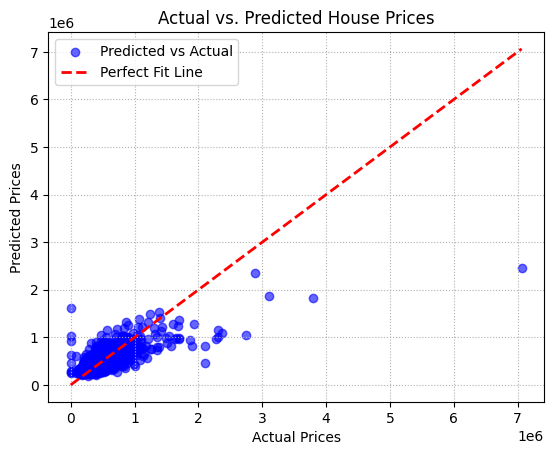

In [46]:
plt.scatter(y_test, y_pred, color='blue', alpha=0.6, label='Predicted vs Actual')
start_point = min(min(y_test), min(y_pred))
end_point = max(max(y_test), max(y_pred))
plt.plot([start_point, end_point], [start_point, end_point], color='red', linestyle='--', linewidth=2, label='Perfect Fit Line')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs. Predicted House Prices")
plt.legend()
plt.grid(True, linestyle=':')
plt.show()

In [44]:
from sklearn.metrics import  r2_score
# 1. R-squared Score (How well your features explain the price variance)
r2 = r2_score(y_test, y_pred)


print(f"R2 Score: {r2:.4f}")


R2 Score: 0.5068


In [45]:
import joblib

joblib.dump(model, "model.pkl")

print("Model saved successfully!")


Model saved successfully!
